In [3]:
from google.colab import files
uploaded = files.upload()


Saving BlinkIT Grocery Data.xlsx to BlinkIT Grocery Data (1).xlsx


In [4]:

!pip install pandas matplotlib scikit-learn openpyxl

In [6]:
import pandas as pd

In [7]:
from google.colab import files
uploaded = files.upload()

Saving BlinkIT Grocery Data.xlsx to BlinkIT Grocery Data (2).xlsx


In [8]:
import os
print(os.listdir())

['.config', 'BlinkIT Grocery Data (2).xlsx', 'BlinkIT Grocery Data.xlsx', 'BlinkIT Grocery Data (1).xlsx', 'sample_data']


In [9]:
df = pd.read_excel("BlinkIT Grocery Data.xlsx")
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [10]:
print(df.columns)

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')


In [11]:
sales_year = df.groupby('Outlet Establishment Year')['Sales'].sum().reset_index()

sales_year

,Outlet Establishment Year,Sales
0,2011,78131.5666
1,2012,130476.8598
2,2014,131809.0156
3,2015,130942.7802
4,2016,132113.3698
5,2017,133103.9070
6,2018,204522.2570
7,2020,129103.9604
8,2022,131477.7764


In [12]:
from sklearn.linear_model import LinearRegression

X = sales_year[['Outlet Establishment Year']]
y = sales_year['Sales']

model = LinearRegression()
model.fit(X, y)

print("Model Trained Successfully")

Model Trained Successfully


In [13]:
future_years = pd.DataFrame({
    'Outlet Establishment Year':
    [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030]
})

future_years['Forecast Sales'] = model.predict(future_years)

future_years

,Outlet Establishment Year,Forecast Sales
0,2023,160756.288583
1,2024,164709.919300
2,2025,168663.550016
3,2026,172617.180733
4,2027,176570.811450
5,2028,180524.442167
6,2029,184478.072884
7,2030,188431.703601


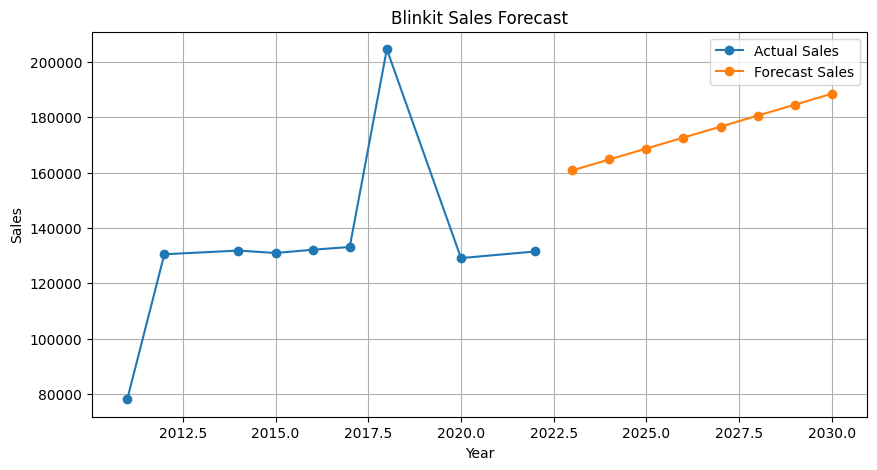

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    sales_year['Outlet Establishment Year'],
    sales_year['Sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    future_years['Outlet Establishment Year'],
    future_years['Forecast Sales'],
    marker='o',
    label='Forecast Sales'
)

plt.title('Blinkit Sales Forecast')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.show()

In [15]:
future_years.to_excel(
    "Blinkit_Forecast.xlsx",
    index=False
)

print("Excel File Created")

Excel File Created


In [16]:
from google.colab import files

files.download("Blinkit_Forecast.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>